# MAE vs RMSE (or SE)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
variance   = 0.5
gamma_true = 1.

def MARE(gamma, gamma_true):
    return np.sum(np.abs(gamma-gamma_true))/len(gamma)/gamma_true

def FSE(gamma, gamma_true):
    return np.sqrt(np.sum(np.power(gamma-gamma_true, 2))/len(gamma))/gamma_true

0.5636550076302662 0.7059304292582658
0.568407578601944 0.712216987060512
0.5655295712523929 0.7252197063810516
0.5676634130542578 0.7354272898553058
0.5503706253440831 0.621272324243691


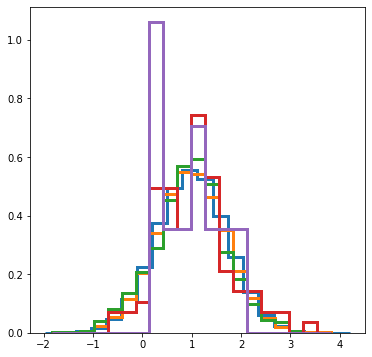

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=100000)
_, bins, _ = ax.hist(gamma, bins=20, density=True, histtype="step", lw=3.);
print(MARE(gamma, gamma_true), FSE(gamma, gamma_true))

gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=10000)
_, bins, _ = ax.hist(gamma, bins=20, density=True, histtype="step", lw=3.);
print(MARE(gamma, gamma_true), FSE(gamma, gamma_true))

gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=1000)
ax.hist(gamma, bins=bins, density=True, histtype="step", lw=3);
print(MARE(gamma, gamma_true), FSE(gamma, gamma_true))

gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=100)
ax.hist(gamma, bins=bins, density=True, histtype="step", lw=3);
print(MARE(gamma, gamma_true), FSE(gamma, gamma_true))

gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=10)
ax.hist(gamma, bins=bins, density=True, histtype="step", lw=3);
print(MARE(gamma, gamma_true), FSE(gamma, gamma_true))

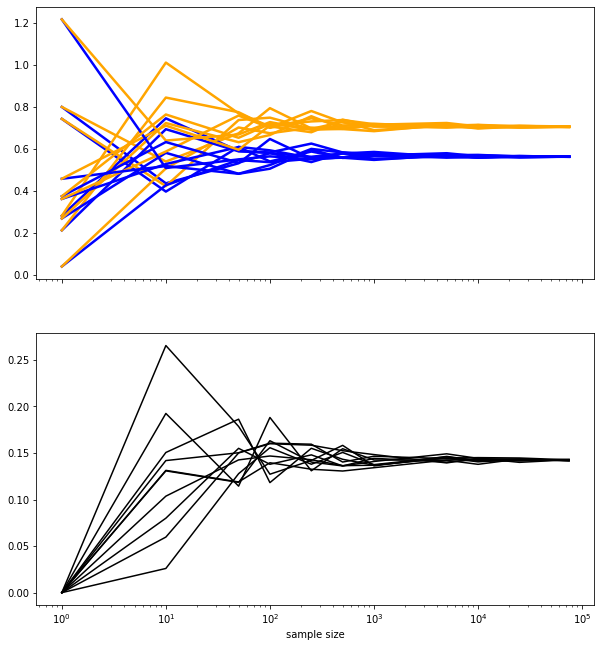

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(10, 11), sharex=True)


for i in range(10):
    size = np.array([1, 10, 50, 100, 250, 500, 1000, 5000, 10000, 25000, 75000])
    _MARE = []; _FSE = []
    for s in size:
        gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=s)
        _MARE.append(MARE(gamma, gamma_true))
        _FSE.append(FSE(gamma, gamma_true))
    _MARE = np.array(_MARE); _FSE = np.array(_FSE)
    
    ax[0].plot(size, _MARE, lw=2.5, color="blue")
    ax[0].plot(size, _FSE, lw=2.5, color="orange")
    #ax[0].plot(size, size*_FSE**2)
    ax[0].set_xscale("log"); #ax[0].set_ylim([0., 1])
    ax[1].plot(size, np.array(_FSE)-np.array(_MARE), color="black")
    ax[1].set_xlabel("sample size")

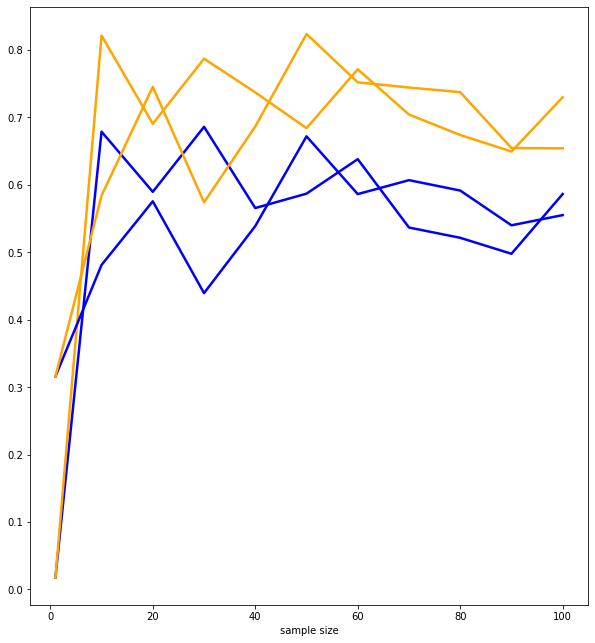

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(10, 11), sharex=True)


for i in range(2):
    size = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
    _MARE = []; _FSE = []
    for s in size:
        gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=s)
        _MARE.append(MARE(gamma, gamma_true))
        _FSE.append(FSE(gamma, gamma_true))
    _MARE = np.array(_MARE); _FSE = np.array(_FSE)
    
    ax.plot(size, _MARE, lw=2.5, color="blue")
    ax.plot(size, _FSE, lw=2.5, color="orange")
    ax.set_xlabel("sample size")

0.7312554299321709
0.7464199395015085
0.9513852218285621
0.6653122192319583
0.6342725107826681
0.45597944321147627
0.5402034256328445
0.6374299733092424
0.44552675474483766
0.7887507888233353
0.5688744330946883 0.6935919030737494
0.12957561030366826 0.13317743360044448 0.6596535706998603
0.6585352724938465
0.6126347005648798
0.7115327811510607
0.5965152442853096
0.6265695914372287
0.6466097382028381
0.7199003168609119
0.6376349305740663
0.6228031682953346
0.6787602448201882
0.5170574495516607 0.6544225843564317
0.02876568471859157 0.039828014518731206 0.6511495988685663


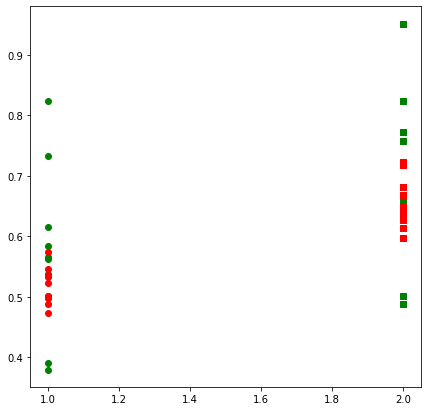

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
_MARE = np.zeros(10); _FSE = np.zeros(10); _std = np.zeros(10)
for i in range(10):
    gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=10)
    print(np.std(gamma))
    ax.scatter(1, MARE(gamma, gamma_true), marker="o", color="g")
    ax.scatter(2, FSE(gamma, gamma_true), marker="s", color="g")
    _MARE[i] = MARE(gamma, gamma_true)
    _FSE[i]  = FSE(gamma, gamma_true)
    _std[i]  = np.std(gamma)
print(np.mean(_MARE), np.mean(_FSE))
print(np.std(_MARE), np.std(_FSE), np.mean(_std))
_mean = np.mean(_std)
_MARE = np.zeros(10); _FSE = np.zeros(10); _std = np.zeros(10)
for i in range(10):
    gamma = np.random.normal(loc=gamma_true, scale=_mean, size=100)
    print(np.std(gamma))
    ax.scatter(1, MARE(gamma, gamma_true), marker="o", color="r")
    ax.scatter(2, FSE(gamma, gamma_true), marker="s", color="r")
    _MARE[i] = MARE(gamma, gamma_true)
    _FSE[i]  = FSE(gamma, gamma_true)
    _std[i]  = np.std(gamma)
print(np.mean(_MARE), np.mean(_FSE))
print(np.std(_MARE), np.std(_FSE), np.mean(_std))

0.7762328490339989
0.7853070057050505
0.6288456979185062
0.7914192587602984
0.4483042130925873
0.44385011599700536
0.8310553970413487
0.7907285427782503
0.8114109584741341
0.4623630974870653
0.5699057662320823 0.7325469570635097
0.13054341251501422 0.15903721819480654 0.1563493939607054
1.2605210413562657
1.1614683383125435
1.3126720913889331
1.4318637135375392
1.1652667797242253
1.1243466924219059
1.3337914462906273
1.2156384441990544
1.253805130193098
1.1702426687569232
0.9977893658725161 1.2469324844146155
0.06173277766074865 0.089968089359374 0.09055455213050237


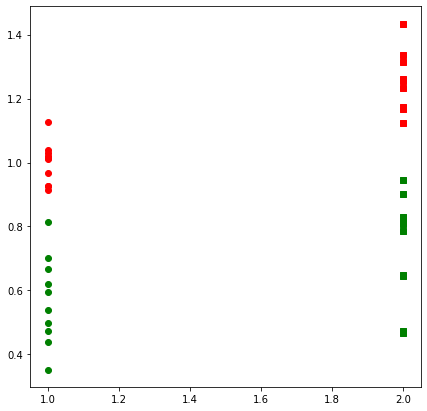

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
_MARE = np.zeros(10); _FSE = np.zeros(10); _std = np.zeros(10)
for i in range(10):
    gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=10)
    print(np.std(gamma))
    ax.scatter(1, MARE(gamma, gamma_true), marker="o", color="g")
    ax.scatter(2, FSE(gamma, gamma_true), marker="s", color="g")
    _MARE[i] = MARE(gamma, gamma_true)
    _FSE[i]  = FSE(gamma, gamma_true)
    _std[i]  = np.std(gamma)
print(np.mean(_MARE), np.mean(_FSE))
print(np.std(_MARE), np.std(_FSE), np.std(_std))
_mean = np.mean(_std)
_MARE = np.zeros(10); _FSE = np.zeros(10); _std = np.zeros(10)
for i in range(10):
    gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(1.5), size=100)
    print(np.std(gamma))
    ax.scatter(1, MARE(gamma, gamma_true), marker="o", color="r")
    ax.scatter(2, FSE(gamma, gamma_true), marker="s", color="r")
    _MARE[i] = MARE(gamma, gamma_true)
    _FSE[i]  = FSE(gamma, gamma_true)
    _std[i]  = np.std(gamma)
print(np.mean(_MARE), np.mean(_FSE))
print(np.std(_MARE), np.std(_FSE), np.std(_std))

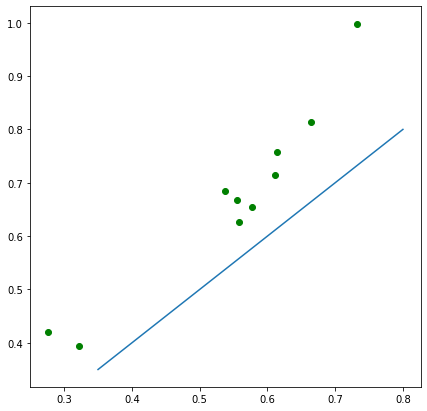

In [66]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7))

for i in range(10):
    gamma = np.random.normal(loc=gamma_true, scale=np.sqrt(variance), size=10)
    
    ax.scatter(MARE(gamma, gamma_true), FSE(gamma, gamma_true), marker="o", color="g")
ax.plot(np.linspace(0.35, 0.8, 10), np.linspace(0.35, 0.8, 10))